Constructing spatial weight matrix...


C:\Users\32003\AppData\Local\Temp\ipykernel_19524\4285970873.py:27: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
C:\Users\32003\anaconda3\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There is 1 island with id: 4631.
  W.__init__(self, neighbors, ids=ids, **kw)
C:\Users\32003\anaconda3\Lib\site-packages\esda\moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


('WARNING: ', 4631, ' is an island (no neighbors)')
Calculating the local Moran index of PC...


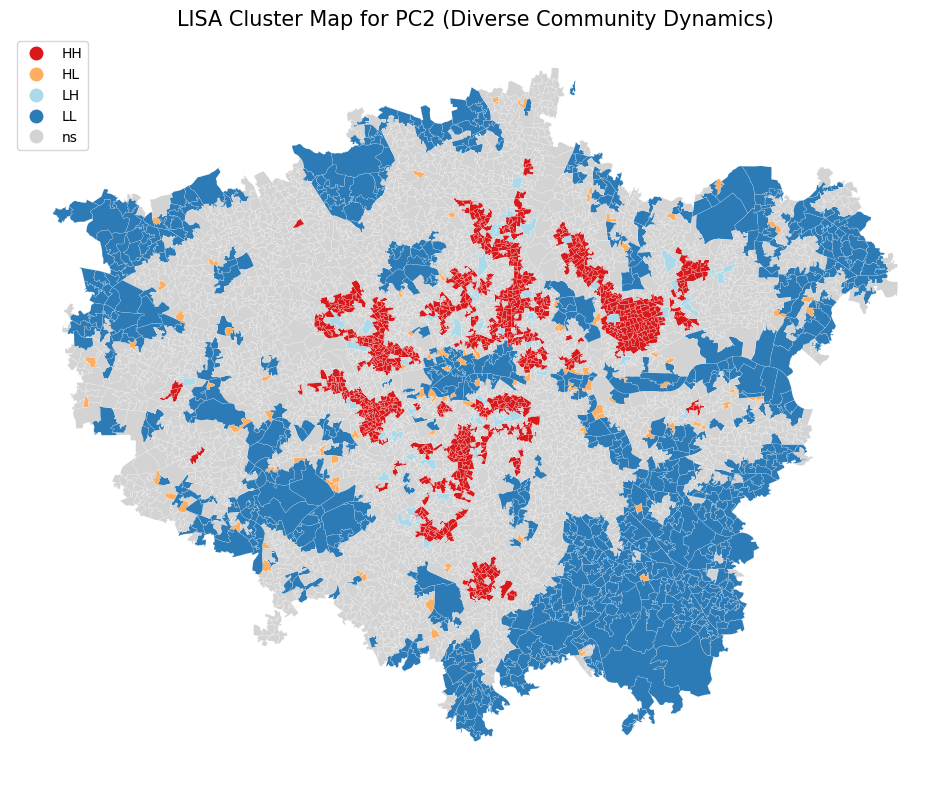

Analysis and correction export complete！


In [14]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.weights import Queen, KNN
from esda.moran import Moran_Local
from splot.esda import lisa_cluster

# ==========================================
# 1. Data loading and preprocessing
# ==========================================
df = pd.read_csv('used data/PCA FinalResult .csv')
gdf_london = gpd.read_file('used data/01_LondonLSOA.shp')

gdf = gdf_london.merge(df, left_on='code', right_on='code')


target_col = '1'  #Decide which PC to analyze!!!!!!!!!!!
gdf = gdf.dropna(subset=[target_col])


# ==========================================
# 2. Constructing the spatial weight matrix (Spatial Weights)
# ==========================================
print("Constructing spatial weight matrix...")

try:
    w = Queen.from_dataframe(gdf)
except:
    print("Isolated islands were detected; the system switched to a KNN (k=8) weight matrix.")
    w = KNN.from_dataframe(gdf, k=8)

w.transform = 'r'

# ==========================================
# 3. calculate Local Moran's I
# ==========================================
print("Calculating the local Moran index of PC...")
y = gdf[target_col].values
moran_loc = Moran_Local(y, w)

# ==========================================
# 4. Visualization results (LISA Cluster Map)
# ==========================================
fig, ax = plt.subplots(figsize=(12, 10))
lisa_cluster(moran_loc, gdf, p=0.05, ax=ax, legend=True, legend_kwds={'loc': 'upper left'})
plt.title('LISA Cluster Map for PC{} (Diverse Community Dynamics)'.format(int(target_col)+1), fontsize=15)
plt.show()

# ==========================================
# 5. Corrected export results (Filtered Export)
# ==========================================
gdf['quadrant'] = moran_loc.q
gdf['p_value'] = moran_loc.p_sim

significance_level = 0.05

gdf['LISA_Cluster_Final'] = gdf.apply(
    lambda x: x['quadrant'] if x['p_value'] <= significance_level else 0, axis=1
)

labels = {
    0: 'Not Significant',
    1: 'HH (High-High)',
    2: 'LH (Low-High)',
    3: 'LL (Low-Low)',
    4: 'HL (High-Low)'
}
gdf['LISA_Label'] = gdf['LISA_Cluster_Final'].map(labels)

output_columns = ['code', 'p_value', 'quadrant', 'LISA_Label']
gdf[output_columns].to_csv('PC{} LISA_Analysis_Result.csv'.format(int(target_col)+1), index=False)
print("Analysis and correction export complete！")